### linear regression

In [34]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [35]:
# Utility function for all 3 datasets
def week1_regression_pipeline(df, features, target, dataset_name):
    print(f"\n===================== {dataset_name} =====================")
    
    # Scale features
    X = df[features]
    y = df[target]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Polynomial Regression
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X_scaled)
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
    model_poly = LinearRegression().fit(X_train, y_train)
    y_pred_poly = model_poly.predict(X_test)
    print("Polynomial Regression R²:", r2_score(y_test, y_pred_poly))
    print("Polynomial Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
    
    # Interaction Terms Only
    poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_inter = poly_inter.fit_transform(X_scaled)
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_inter, y, test_size=0.2, random_state=42)
    model_inter = LinearRegression().fit(X_train_i, y_train_i)
    y_pred_inter = model_inter.predict(X_test_i)
    print("Interaction Terms Only R²:", r2_score(y_test_i, y_pred_inter))
    print("Interaction Terms Only RMSE:", np.sqrt(mean_squared_error(y_test_i, y_pred_inter)))
    
    # VIF
    X_vif = pd.DataFrame(X_scaled, columns=features)
    X_vif_const = sm.add_constant(X_vif)
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X_vif.columns
    vif_df["VIF"] = [variance_inflation_factor(X_vif_const.values, i+1) for i in range(X_vif.shape[1])]
    print("\nVIF Table:")
    print(vif_df.sort_values(by="VIF", ascending=False).to_string(index=False))
    
    # OLS Summary
    ols_model = sm.OLS(y, sm.add_constant(X_scaled)).fit()
    print("\nOLS Summary:")
    print(ols_model.summary())

In [36]:
# Loading data
austin_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_austin_data.csv")
airbnb_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_airbnb_data.csv")
real_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/updated_real_estate.csv")


In [37]:
# Dataset specific variables 

# Austin Dataset
austin_features = ['livingAreaSqFt', 'numOfBathrooms', 'numOfBedrooms', 'lotSizeSqFt',
                   'avgSchoolRating', 'yearBuilt', 'garageSpaces', 'parkingSpaces',
                   'homeType_Condo', 'homeType_Single Family', 'homeType_Townhouse']
austin_target = 'latestPrice'

# Airbnb Dataset
airbnb_features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
                   'reviews_per_month', 'calculated_host_listings_count',
                   'availability_365', 'number_of_reviews_ltm',
                   'room_type_Entire home/apt', 'room_type_Private room']
airbnb_target = 'price'

# Real Estate Dataset
real_features = ['bed', 'bath', 'acre_lot', 'house_size']
real_target = 'price'

# Running pipelines
week1_regression_pipeline(austin_df, austin_features, austin_target, "Austin Housing Dataset")
week1_regression_pipeline(airbnb_df, airbnb_features, airbnb_target, "Airbnb Dataset")
week1_regression_pipeline(real_df, real_features, real_target, "Real Estate Dataset")


===================== Austin Housing Dataset =====================
Polynomial Regression R²: 0.3756539046520345
Polynomial Regression RMSE: 384404.30959068483
Interaction Terms Only R²: 0.3740751593713256
Interaction Terms Only RMSE: 384890.01242098055

VIF Table:
               Feature        VIF
          garageSpaces 205.574005
         parkingSpaces 205.373335
homeType_Single Family   3.486263
        homeType_Condo   2.865955
        numOfBathrooms   2.193050
         numOfBedrooms   1.818171
    homeType_Townhouse   1.693861
        livingAreaSqFt   1.654564
             yearBuilt   1.246174
       avgSchoolRating   1.211006
           lotSizeSqFt   1.000914

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:            latestPrice   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     75

/Users/sohanaziz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)
/Users/sohanaziz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


Polynomial Regression R²: -0.05697146481779747
Polynomial Regression RMSE: 1902242.9644047192
Interaction Terms Only R²: 0.05360963710966549
Interaction Terms Only RMSE: 1799987.585246432


/Users/sohanaziz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)



VIF Table:
   Feature      VIF
      bath 1.512567
       bed 1.512566
  acre_lot 1.000004
house_size 1.000001

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                 3.062e+04
Date:                Sun, 29 Jun 2025   Prob (F-statistic):               0.00
Time:                        04:50:21   Log-Likelihood:            -3.4830e+07
No. Observations:             2223239   AIC:                         6.966e+07
Df Residuals:                 2223234   BIC:                         6.966e+07
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----

**Austin Housing Dataset**

Polynomial R² = 0.377

A moderate model fit, quite reasonable for real estate pricing, where nonlinearity and external market influences are common.

VIF Values: Mostly < 5 . Suggests low multicollinearity. Key predictors like square footage, bathrooms, and school ratings contribute uniquely and meaningfully.

Conclusion:
This dataset has a solid structure with informative features and minimal multicollinearity. It is well-suited for more complex modeling, such as interaction terms, regularization, or tree-based methods like Random Forest or XGBoost.

**Inside Airbnb Dataset**

Polynomial R² = 0.027

Very poor fit, the model explains less than 3% of the variance in listing prices.

VIF ~14.9 for room_type_* variables. Indicates high multicollinearity, likely due to including all dummy variables. These mutually exclusive categories are highly correlated.

Conclusion: 
The model’s low performance suggests that Airbnb prices are driven by qualitative and external features (e.g., reviews, photos, neighborhood appeal) that aren’t captured in the current numeric data. This dataset may benefit more from NLP (text analysis), clustering, or nonlinear tree-based models rather than traditional regression.

**USA Real Estate Dataset**

Polynomial R² = -0.057

Negative R² means the model performs worse than simply predicting the mean, essentially no predictive value.

VIFs < 1.5 . No multicollinearity problems, but predictors like house_size were not statistically significant.

Conclusion:
The weak performance is likely due to missing key predictors such as location, renovation status, property condition, or local market factors. The dataset lacks depth for regression in its current form, so it might be excluded from further analysis.


**Since the Airbnb Dataset is poor, I will be using another dataset on the same Airbnb provided in last semester with different variables, and this dataset will be more suitable for further analysis.**

I will be doing some EDA on it before proceeding.

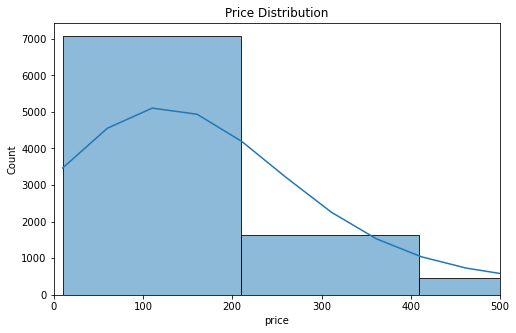

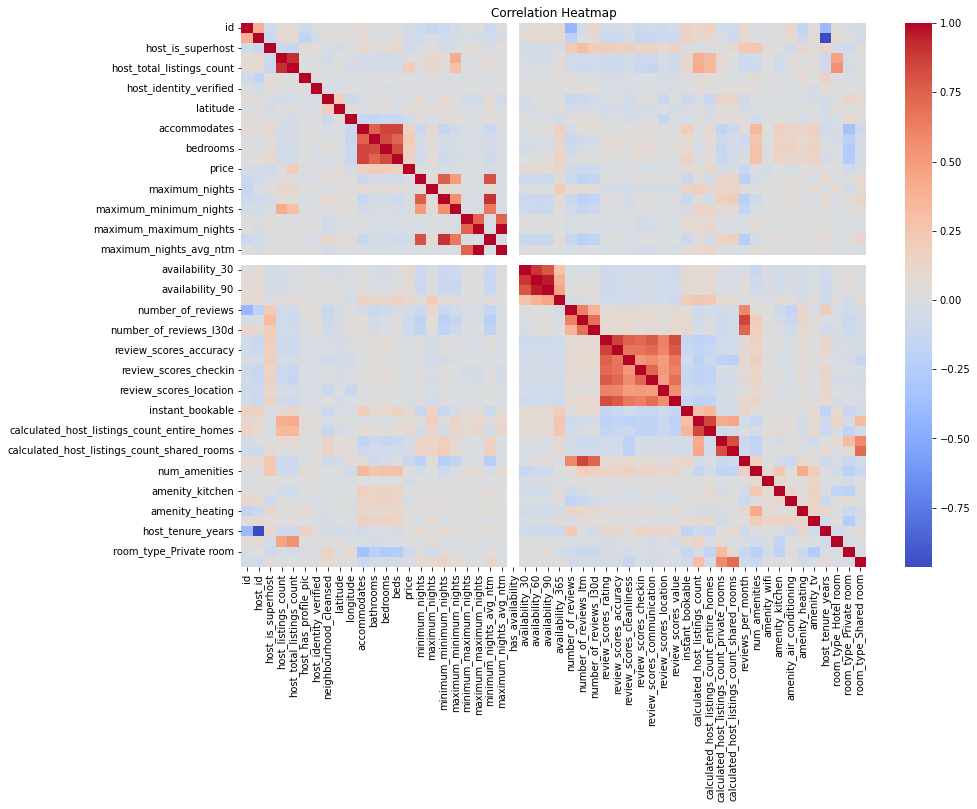

Final shape: (9697, 69)
      id last_scraped                                             name  \
1  70812   2024-12-15                  1 Bedroom Apt; Above the Studio   
3  73005   2024-12-14    3BR Convenient Gated Townhome w/ Pool Access!   
4  73289   2024-12-15                     Simple 2/2 in Central Austin   
5  74318   2024-12-15                        Private Guest House 78704   
6  75957   2024-12-15  Charming 1 bedroom Guesthouse Apt. in Tarrytown   

   host_id     host_name host_since host_location  host_response_time  \
1   268988     Stephanie 2010-10-23    Austin, TX      within an hour   
3   128514        Vivian 2010-05-20    Austin, TX  within a few hours   
4   382510     Christina 2011-02-08    Austin, TX        within a day   
5   387918  Amy & Justin 2011-02-11    Austin, TX      within an hour   
6   404260         Kelly 2011-02-22    Austin, TX      within an hour   

  host_response_rate host_acceptance_rate  host_is_superhost  \
1               100%        

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Load dataset
df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/Arvinds datasets/listings.csv")
pd.set_option('display.max_columns', None)

# Drop irrelevant or mostly-null columns
df.drop(columns=[
    'listing_url', 'scrape_id', 'source', 'description', 'neighborhood_overview',
    'picture_url', 'host_url', 'host_about', 'host_thumbnail_url', 'host_picture_url',
    'calendar_updated', 'license', 'host_verifications', 'neighbourhood_group_cleansed'
], inplace=True)

# Convert date columns
date_cols = ['last_scraped', 'host_since', 'first_review', 'last_review', 'calendar_last_scraped']
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')

# Clean and filter price
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df = df[df['price'].notnull()]

# Map binary strings to 1/0
binary_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable']
df[binary_cols] = df[binary_cols].replace({'t': 1, 'f': 0})

# Extract bathrooms from bathrooms_text
df['bathrooms_text'] = df['bathrooms_text'].astype(str)
df['bathrooms_text_clean'] = df['bathrooms_text'].str.extract(r'([\d\.]+)').astype(float)

# Fill missing 'bathrooms' with extracted values
if 'bathrooms' in df.columns:
    df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms_text_clean'])

# Drop original text column and helper column
df.drop(columns=['bathrooms_text', 'bathrooms_text_clean'], inplace=True)

# Fill missing numerical values with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Count and flag amenities
df['amenities'] = df['amenities'].astype(str)
df['num_amenities'] = df['amenities'].apply(lambda x: len(re.findall(r'"(.*?)"', x)))
for amenity in ['Wifi', 'Kitchen', 'Air conditioning', 'Heating', 'TV']:
    df[f'amenity_{amenity.replace(" ", "_").lower()}'] = df['amenities'].str.contains(amenity, case=False).astype(int)

# Host tenure in years
df['host_tenure_years'] = (pd.to_datetime('today') - df['host_since']).dt.days / 365

# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop any rows that STILL have any nulls after all this
df = df.replace([np.inf, -np.inf], np.nan)
df.dropna(inplace=True)

# One-hot encoding for room_type
df = pd.get_dummies(df, columns=['room_type'], drop_first=True)

# Visualizations
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlim(0, 500)
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Output shape and preview
print("Final shape:", df.shape)
print(df.head())

In this step, I performed exploratory data cleaning and transformation on the Airbnb listings dataset to prepare it for analysis and modeling. I began by dropping columns that were irrelevant, redundant, or too sparse to be useful, such as URLs, image links, and verbose text fields like descriptions. Date fields were converted to proper datetime formats, and the price column was cleaned by removing currency symbols and converting it to numeric format.

Binary variables encoded as 't' and 'f' were mapped to 1s and 0s for easier analysis. I handled missing values in key numeric columns like bedrooms, beds, and bathrooms by imputing medians, and for bathrooms, I also extracted numbers from the textual field bathrooms_text to improve accuracy. Amenities were parsed to count how many each listing offered, and I created binary flags for common ones like Wifi and Air Conditioning.

I also engineered new features such as host_tenure_years (to represent host experience) and extracted verification information (e.g., phone, email). Listings with missing core review metrics were removed, and duplicates were dropped to ensure data quality. Finally, categorical variables like room_type was one-hot encoded, and some visualizations were created to understand price distribution and correlations.

In [39]:
df.to_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/listings_cleaned.csv", index=False)

Doing linear regression with polynomial and interaction terms, multicollinearity check via VIF, OLS summary, and handling categorical and continuous features on new Airbnb cleaned dataset.

In [40]:
airbnb_new = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/listings_cleaned.csv")

features = [
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
    'room_type_Private room', 'room_type_Shared room' 
]

target = 'price'

# Run the pipeline]

week1_regression_pipeline(airbnb_new, features, target, "Airbnb Cleaned Dataset")



===================== Airbnb Cleaned Dataset =====================
Polynomial Regression R²: 0.0015688635046928745
Polynomial Regression RMSE: 494.9893121561137
Interaction Terms Only R²: 0.004977885861784048
Interaction Terms Only RMSE: 494.143549030702

VIF Table:
                       Feature      VIF
             reviews_per_month 1.611670
             number_of_reviews 1.540283
calculated_host_listings_count 1.189617
         room_type_Shared room 1.123674
              availability_365 1.077304
                minimum_nights 1.059139
        room_type_Private room 1.034659
                     longitude 1.024777
                      latitude 1.008680

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     49.13
Da

/Users/sohanaziz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)
